# Building a Reliable AI Agent from Scratch with a Small Local LLM

In this post, we build a ReAct agent from scratch on top of a small local model and then improve it one step at a time. After every improvement, we run the **same test set** and record the results in a **scoreboard**, so you can see exactly what each upgrade fixes, and what it doesn't.

A [**ReAct**](https://arxiv.org/pdf/2210.03629) agent (short for Reasoning and Acting) is an AI architecture that allows a Large Language Model (LLM) to solve complex tasks by alternating between "thinking" and "taking action" in a continuous loop.

**How it works**

Instead of trying to answer a complex prompt all at once (which often leads to hallucinations, especially with small LLMs), a ReAct agent breaks the problem down using a Thought → Action → Observation loop:
1. **Thought:** The model reasons about the problem and plans its next step ("I need to find the current stock price of Nordvik Energy").
2. **Action:** It executes a specific tool call to interact with the outside world, such as searching the web, querying a database, or calling an API.
3. **Observation:** It reads the result returned by that tool ("NVKE is at 84.20 USD").

The agent feeds this new observation back into its context and repeats the loop until it has enough information to deliver a grounded final answer.

**Why it was a game-changer for AI**

- **Fewer hallucinations:** Because the agent grounds its reasoning in external data rather than relying solely on its static training weights, it makes up facts much less often. (In the original paper, ReAct alone did not beat chain-of-thought on every benchmark; the best results came from combining the two.)
- **Dynamic problem solving:** Unlike rigid, hard-coded workflows, a ReAct agent can adapt on the fly if a tool returns an error or unexpected data.
- **Transparency:** It leaves a clear "scratchpad" trail of thoughts and actions, which makes it much easier for developers to debug the agent's decisions. Keep in mind, though, that the written thoughts are not guaranteed to reflect the model's true internal reasoning.

## How this post is organised

We start with the simplest possible agent and add one improvement per stage. Each stage targets a failure that we can see in the previous stage's results:

| Stage | What we add | Which failure we target |
|---|---|---|
| 0 | A baseline ReAct loop with a text format | (our starting point) |
| 1 | A finish rule in the prompt | The agent doesn't know when to give up |
| 2 | A self-correction (reflection) loop | The agent doesn't recover from tool errors |
| 3 | Constrained JSON decoding | The model breaks the output format |
| 4 | A company search tool | The agent guesses tickers or picks the wrong asset |
| 5 | Parallel tool calls | Questions about several companies need too many steps |

After Stage 5, we look at the problem that all these upgrades create together: an ever-growing prompt.

Finally, we rebuild the Stage 5 agent with [**LangGraph**](https://langchain-ai.github.io/langgraph/), a popular framework that models agents as graphs, and run it through the same test set. This shows which parts of our hand-written code a framework can replace (the loop, the state, tool execution and routing), which parts stay our job (the prompt, the tools, the schema and constrained decoding), and whether the switch changes the results.

An optional appendix shows how to connect the agent to live market data from Yahoo Finance.

## Setup

The code was tested with Python 3.12, `transformers` 5.x and `outlines` 1.3. Note that Outlines 1.x has a completely different API from the 0.x versions.

We use [Phi-4-mini-instruct](https://huggingface.co/microsoft/Phi-4-mini-instruct), which has 3.8B parameters and needs about 8 GB of memory in bfloat16, so a GPU is recommended. If you want to try Llama 3 instead, note that it's a gated model: you have to accept Meta's license on Hugging Face and set the `HF_TOKEN` environment variable.

In [ ]:
%pip install -q torch "transformers>=4.56" accelerate "outlines>=1.0,<2" "pydantic>=2" pandas matplotlib
# Only needed for the optional "going live" appendix at the end:
# %pip install -q "yfinance>=0.2.54"

In [1]:
# Import all dependencies we need
import re
import json
import difflib
from dataclasses import dataclass, field
from functools import partial
from typing import Annotated, Literal, Optional, Union
from concurrent.futures import ThreadPoolExecutor

import torch
import outlines
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
# Load a small local model from Hugging Face
# Using microsoft/Phi-4-mini-instruct (or meta-llama/Meta-Llama-3-8B-Instruct, which is gated)
model_id = "microsoft/Phi-4-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto")

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

## A fictional stock market

Our agent will be a stock-market assistant. Instead of connecting it to a live data source right away, we give it a small **fictional market** with frozen prices. This may look like a shortcut, but it's what makes the rest of the post work:

- **Reproducible results.** Live prices change every minute and live APIs get rate-limited. With frozen data, we get the same results every time we run the notebook.
- **No memorised answers.** A model knows real tickers like AAPL from its training data, so with real companies we can't tell whether it used a tool or just remembered. Nobody has ever heard of Nordvik Energy, so the agent *has to* use its tools, and any price that didn't come from a tool is a hallucination by definition.
- **An answer key.** Because we know every correct answer, we can score the agent automatically instead of eyeballing a few runs.
- **Deliberate traps.** We can plant exactly the problems we want each upgrade to solve.

The market contains 14 listed assets, 2 unlisted companies and a few traps:
- **Similar names:** Tessera Robotics and Tessera Materials are different companies.
- **A renamed ticker:** Orbital Pixel Games traded as `PXL` until 2024 and is now `OPXG`. `PXL` now belongs to an unrelated leveraged ETF. (This really happens: Meta's old ticker `FB` now belongs to an ETF.)
- **A private company with a look-alike fund:** Maplestone Logistics is not publicly traded, but there is an ETF with "Maplestone" in its name.
- **A subsidiary:** Snapfolio is owned by Orbital Pixel Games and isn't listed on its own.
- **A flaky service:** the first price request for `CRVD` times out, like a real API sometimes does.

In [3]:
# Every listed asset in our fictional market: ticker -> (name, type, price in USD).
# Prices are a frozen snapshot, so every run of this notebook sees exactly the same data.
LISTED = {
    "NVKE":    ("Nordvik Energy ASA",          "EQUITY",         84.20),
    "HGRD":    ("Helio Grid Systems Inc.",     "EQUITY",         23.75),
    "QFB":     ("Quillfeather Books Ltd.",     "EQUITY",         12.40),
    "BWF":     ("Brightwater Foods Corp.",     "EQUITY",         41.10),
    "TSRX":    ("Tessera Robotics Inc.",       "EQUITY",        156.30),
    "TSMT":    ("Tessera Materials Group",     "EQUITY",         38.90),
    "CRVD":    ("Corvid Aerospace Corp.",      "EQUITY",        212.05),
    "LHB":     ("Lumen Harbor Bank",           "EQUITY",         57.60),
    "PNCP":    ("Pinecrest Pharma Inc.",       "EQUITY",          9.85),
    "ZPHR":    ("Zephyr Mobility Inc.",        "EQUITY",         33.35),
    "OPXG":    ("Orbital Pixel Games Inc.",    "EQUITY",         47.15),
    "PXL":     ("Pixel Leveraged Tech ETF",    "ETF",            18.20),
    "MSCX":    ("Maplestone Supply Chain ETF", "ETF",            27.80),
    "AUR-USD": ("Aurum Coin USD",              "CRYPTOCURRENCY", 1842.50),
}

# Companies that exist, but are NOT listed on any exchange.
UNLISTED = {
    "Maplestone Logistics": "PRIVATE, not publicly traded",
    "Snapfolio":            "SUBSIDIARY of Orbital Pixel Games Inc. (OPXG), not listed on its own",
}

# Former tickers, so that a search for "PXL" can also find Orbital Pixel Games.
FORMER_TICKERS = {"OPXG": "PXL"}

pd.DataFrame([(t, n, k, p) for t, (n, k, p) in LISTED.items()],
             columns=["Ticker", "Name", "Type", "Price (USD)"])

,Ticker,Name,Type,Price (USD)
0,NVKE,Nordvik Energy ASA,EQUITY,84.20
1,HGRD,Helio Grid Systems Inc.,EQUITY,23.75
2,QFB,Quillfeather Books Ltd.,EQUITY,12.40
3,BWF,Brightwater Foods Corp.,EQUITY,41.10
4,TSRX,Tessera Robotics Inc.,EQUITY,156.30
5,TSMT,Tessera Materials Group,EQUITY,38.90
6,CRVD,Corvid Aerospace Corp.,EQUITY,212.05
7,LHB,Lumen Harbor Bank,EQUITY,57.60
8,PNCP,Pinecrest Pharma Inc.,EQUITY,9.85
9,ZPHR,Zephyr Mobility Inc.,EQUITY,33.35


### The first tool: `get_stock_price`

Our first toolbox contains a single tool. Like a real market-data API, it returns the asset's name together with its price. A careful agent can use the name to notice when a ticker belongs to a different asset than the one the user asked about.

The tool also simulates a flaky service: the first request for `CRVD` fails with a temporary error. `reset_market()` resets this state, and the evaluation calls it before every question.

In [4]:
_request_counts = {}

def reset_market():
    """Reset per-question state (used by the simulated flaky price service)."""
    _request_counts.clear()

def get_stock_price(ticker: str) -> str:
    """Returns the latest price for an EXACT ticker symbol."""
    t = ticker.strip().strip("'\"").upper()
    if t not in LISTED:
        return f"ERROR: Ticker '{ticker}' not found."

    # Simulated flaky service: the first request for CRVD times out.
    _request_counts[t] = _request_counts.get(t, 0) + 1
    if t == "CRVD" and _request_counts[t] == 1:
        return ("ERROR: Price service timed out for 'CRVD'. This is a temporary error; "
                "the same request may work if you retry.")

    name, _, price = LISTED[t]
    return f"The latest price of {t} ({name}) is {price:.2f} USD."

def run_tool(tools: dict, name: str, arg: str) -> str:
    """Run a tool by name and turn every failure into an ERROR observation."""
    if name not in tools:
        return f"ERROR: Tool '{name}' does not exist. Available tools: {list(tools)}"
    try:
        return tools[name](arg)
    except Exception as e:
        return f"ERROR: Tool '{name}' raised {type(e).__name__}: {e}"

# Tool registry for stages 0 to 3
TOOLS_V1 = {"get_stock_price": get_stock_price}

print(get_stock_price("NVKE"))
print(get_stock_price("CRVD"))   # first request fails...
print(get_stock_price("CRVD"))   # ...and the retry works
reset_market()

The latest price of NVKE (Nordvik Energy ASA) is 84.20 USD.
ERROR: Price service timed out for 'CRVD'. This is a temporary error; the same request may work if you retry.
The latest price of CRVD (Corvid Aerospace Corp.) is 212.05 USD.


## The test set and the scoreboard

Every stage is evaluated on the same 12 questions. Each question targets a specific skill, and some have no price as the correct answer: for a private company or a question our tools can't answer, the right answer is to say so.

In [5]:
# expect: the prices a correct answer must contain, or None if the correct answer is
#         "this can't be answered" (the answer must not contain any price).
# also_ok: an alternative correct answer (for Snapfolio, pointing to its parent company is fine too).
EVAL_SET = [
    dict(id="Q1",  category="Direct ticker",     expect=[84.20],
         question="What is the current price of NVKE?"),
    dict(id="Q2",  category="Company name",      expect=[41.10],
         question="What is the stock price of Brightwater Foods?"),
    dict(id="Q3",  category="Similar names",     expect=[156.30],
         question="How much does one share of Tessera Robotics cost?"),
    dict(id="Q4",  category="Misspelled name",   expect=[12.40],
         question="What's the share price of Quilfeather Books?"),
    dict(id="Q5",  category="Cryptocurrency",    expect=[1842.50],
         question="How much is one Aurum Coin worth in USD?"),
    dict(id="Q6",  category="Flaky tool",        expect=[212.05],
         question="What is the current price of CRVD?"),
    dict(id="Q7",  category="Renamed ticker",    expect=[47.15],
         question="What is the stock price of Orbital Pixel Games? I think its ticker is PXL."),
    dict(id="Q8",  category="Private company",   expect=None,
         question="What is the stock price of Maplestone Logistics?"),
    dict(id="Q9",  category="Subsidiary",        expect=None, also_ok=[47.15],
         question="What is the stock price of Snapfolio?"),
    dict(id="Q10", category="No suitable tool",  expect=None,
         question="What was the average closing price of LHB last month?"),
    dict(id="Q11", category="Several tickers",   expect=[23.75, 33.35],
         question="Give me the current prices of HGRD and ZPHR."),
    dict(id="Q12", category="Several names",     expect=[9.85, 38.90, 57.60],
         question="Give me the current stock prices of Pinecrest Pharma, Tessera Materials and Lumen Harbor Bank."),
]

### Scoring

Every agent returns an `AgentResult` with its final answer and a trace of everything it did. We score each answer by checking the **prices** it contains against the answer key and against the tool results:

| Outcome | Meaning |
|---|---|
| ✅ Correct | The answer contains the expected price(s). For unanswerable questions: the answer contains no price. |
| 🎭 Invented | The answer contains a price that never appeared in any tool result. This is a hallucination. |
| 🔀 Wrong | All prices came from tools, but they are the wrong ones (for example, the price of the wrong asset). |
| 🙅 Gave up | We expected a price, but the agent answered without one. |
| 💥 No answer | The agent aborted or hit the step limit. |

Besides the outcomes, the scoreboard tracks **format errors** (outputs our parser couldn't use), the average number of **LLM calls** per question, and the average **prompt size** at the last LLM call.

This scoring is deliberately simple, so it has limits: it only looks at numbers with decimals (like `84.20`), and it doesn't judge the wording. It's good enough to compare stages, but always read a few answers yourself (`show_answers()` below helps). Also keep in mind that 12 questions is a small test set: treat a difference of one question as noise, not as a trend.

All generation in this post is greedy (`do_sample=False`), so every stage sees exactly the same conditions and results are repeatable.

In [6]:
MAX_STEPS = 6   # the same step budget for every stage

@dataclass
class AgentResult:
    answer: Optional[str] = None
    status: str = "max_steps"                          # "answered", "aborted" or "max_steps"
    llm_calls: int = 0
    format_errors: int = 0
    prompt_tokens: list = field(default_factory=list)  # prompt size at each LLM call
    tool_calls: list = field(default_factory=list)     # (tool_name, argument, observation)

    def record(self, name, arg, observation):
        self.tool_calls.append((name, arg, observation))

    def finish(self, answer):
        self.answer, self.status = answer, "answered"
        return self

    def abort(self, reason):
        self.answer, self.status = reason, "aborted"
        return self

def make_logger(verbose: bool):
    return print if verbose else (lambda *args, **kwargs: None)

In [7]:
# Prices like 84.20, 1842.5 or 1,842.50 (numbers without decimals, like years, are ignored)
PRICE_RE = re.compile(r"\d{1,3}(?:,\d{3})+(?:\.\d+)?|\d+\.\d+")

def extract_prices(text: str) -> list:
    return [float(p.replace(",", "")) for p in PRICE_RE.findall(text or "")]

def contains(prices, value, tol=0.01):
    return any(abs(p - value) <= tol for p in prices)

def score(item: dict, res: AgentResult) -> str:
    if res.status != "answered":
        return "💥 No answer"
    answer_prices = extract_prices(res.answer)
    tool_prices = extract_prices(" ".join(obs for _, _, obs in res.tool_calls))

    if any(not contains(tool_prices, p) for p in answer_prices):
        return "🎭 Invented"
    if item["expect"] is None:                    # the correct answer contains no price...
        if not answer_prices:
            return "✅ Correct"
        also_ok = item.get("also_ok")             # ...unless an alternative answer is allowed
        if also_ok and all(contains(answer_prices, p) for p in also_ok):
            return "✅ Correct"
        return "🔀 Wrong"
    if all(contains(answer_prices, p) for p in item["expect"]):
        return "✅ Correct"
    return "🙅 Gave up" if not answer_prices else "🔀 Wrong"

In [8]:
RESULTS = {}   # stage name -> list of per-question results
OUTCOMES = ["✅ Correct", "🎭 Invented", "🔀 Wrong", "🙅 Gave up", "💥 No answer"]

def evaluate(stage: str, agent_fn, eval_set=EVAL_SET):
    """Run every question through agent_fn, score it, and add a row to the scoreboard."""
    print(f"Evaluating: {stage}")
    rows = []
    for item in eval_set:
        reset_market()
        res = agent_fn(item["question"], verbose=False)
        outcome = score(item, res)
        rows.append(dict(id=item["id"], category=item["category"], question=item["question"],
                         outcome=outcome, answer=res.answer, llm_calls=res.llm_calls,
                         format_errors=res.format_errors, prompt_tokens=res.prompt_tokens))
        print(f"  {item['id']:>4} {outcome:<13} ({res.llm_calls} LLM calls)")
    RESULTS[stage] = rows
    return show_scoreboard()

def show_scoreboard():
    table = []
    for stage, rows in RESULTS.items():
        outcomes = [r["outcome"] for r in rows]
        table.append({
            "Stage": stage,
            **{o: outcomes.count(o) for o in OUTCOMES},
            "Format errors": sum(r["format_errors"] for r in rows),
            "Avg LLM calls": round(sum(r["llm_calls"] for r in rows) / len(rows), 1),
            "Avg prompt tokens": round(sum(r["prompt_tokens"][-1] for r in rows if r["prompt_tokens"]) / len(rows)),
        })
    return pd.DataFrame(table).set_index("Stage")

def show_matrix():
    """Outcome of every question at every stage."""
    first = next(iter(RESULTS.values()))
    matrix = pd.DataFrame({stage: [r["outcome"][0] for r in rows] for stage, rows in RESULTS.items()},
                          index=[f"{r['id']} {r['category']}" for r in first])
    return matrix

def show_answers(stage: str):
    """The final answer of every question at one stage."""
    with pd.option_context("display.max_colwidth", None):
        return pd.DataFrame(RESULTS[stage])[["id", "outcome", "answer"]].set_index("id")

def demo(agent_fn, question_id: str):
    """Run one test question with full logging, and score it."""
    item = next(i for i in EVAL_SET if i["id"] == question_id)
    reset_market()
    res = agent_fn(item["question"], verbose=True)
    print(f"\n💬 Final answer: {res.answer}")
    print(f"📊 Outcome: {score(item, res)} ({res.llm_calls} LLM calls)")

## Stage 0: a baseline ReAct agent

Smaller models (such as Llama 3 8B, Mistral 7B, or Phi-3) can struggle to follow full JSON tool-calling schemas reliably, even when their chat templates support tool calling. So we start with the simplest and most transparent approach: a structured text prompt plus a custom Python parser.

### The strict ReAct prompt
Small models need explicit formatting rules so that our regex parser can reliably read their output. We instruct the model to output a specific pattern: `Thought: ...`, `Action: tool_name[argument]`, and then stop.

In [9]:
TOOLS_TEXT_V1 = """Available tools:
- get_stock_price[ticker]: Returns the latest price for an EXACT ticker symbol. Example: get_stock_price[ACMW]
  Stock tickers are plain symbols like ACMW: never add a suffix to them.
  Only cryptocurrency tickers end in '-USD', e.g. get_stock_price[EXC-USD].
"""

FORMAT_RULES = """
Your responses MUST strictly follow this format:
Thought: Reason about what you need to do next.
Action: tool_name[argument_value]

When you finally know the answer, use this format:
Thought: I now have the final answer.
Final Answer: [Your complete response here]
"""

SYSTEM_PROMPT_REACT = ("You are a helpful stock-market assistant operating in a ReAct loop.\n"
                       + TOOLS_TEXT_V1 + FORMAT_RULES)

### The ReAct loop and parser

We need code that parses the `Action: tool_name[argument]` text, runs the Python function, appends `Observation: ...` to the prompt, and feeds everything back into the model.

Two details matter here:
- **Stop strings.** We stop generation as soon as the model writes `\nObservation:`. Without this, the model would happily invent its own tool result and carry on as if the tool had run. Observations must always come from real code, never from the model.
- **One growing prompt.** The chat template is applied only once, to the system and user messages. After that, the model's thoughts and actions and our observations are appended as plain text inside a single assistant turn. This is the simplest way to implement the loop, and it keeps the text format identical to what the prompt describes.

First, two small helpers that all text-based stages share:

In [10]:
STOP_STRINGS = ["\nObservation:", "<|end|>"]

def start_prompt(system_prompt: str, question: str) -> str:
    messages = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": question}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def count_tokens(text: str) -> int:
    return len(tokenizer(text).input_ids)

def generate_text(prompt: str, max_new_tokens: int = 250) -> str:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,              # deterministic: helps small models hold the format
        stop_strings=STOP_STRINGS,    # stop before the model invents its own Observation
        tokenizer=tokenizer,
        pad_token_id=tokenizer.eos_token_id,
    )
    # Decode only the newly generated tokens
    text = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True)
    # Stop strings stay in the decoded text. Drop a trailing "Observation:" so it
    # isn't written twice when we append the real observation.
    return re.sub(r"\s*Observation:\s*$", "", text)

ACTION_RE = re.compile(r"Action:\s*(\w+)\[(.*?)\]")

In [11]:
def run_react_agent(question: str, system_prompt: str = SYSTEM_PROMPT_REACT, tools: dict = TOOLS_V1,
                    max_steps: int = MAX_STEPS, verbose: bool = True) -> AgentResult:
    log = make_logger(verbose)
    res = AgentResult()
    prompt = start_prompt(system_prompt, question)
    log(f"🚀 ReAct agent\nQuestion: {question}\n" + "=" * 40)

    for step in range(max_steps):
        res.llm_calls += 1
        res.prompt_tokens.append(count_tokens(prompt))
        text = generate_text(prompt)
        log(f"\n🎬 [Step {step + 1}] Model output:\n{text.strip()}")

        # Append the model's thoughts to the running prompt
        prompt += text

        # Check if the model has provided the Final Answer
        if "Final Answer:" in text:
            return res.finish(text.split("Final Answer:")[-1].strip())

        # Parse the Action: searches for tool_name[argument]
        match = ACTION_RE.search(text)
        if match:
            name, arg = match.group(1), match.group(2).strip()
            observation = run_tool(tools, name, arg)
            res.record(name, arg, observation)
            log(f"🛠️ {name}({arg!r}) → {observation}")
            # Inject the observation so the model reads it in the next step
            prompt += f"\nObservation: {observation}\n"
        else:
            # The model broke the format: nudge it to recover
            res.format_errors += 1
            log("⚠️ Formatting error, forcing a recovery step.")
            prompt += ("\nObservation: Invalid format. You must choose an Action: tool_name[arg] "
                       "or provide a Final Answer.\n")

    return res   # status stays "max_steps"

Let's try two questions: one easy (the user gives the exact ticker) and one tricky (a private company, which has no price at all).

In [12]:
demo(run_react_agent, "Q1")

🚀 ReAct agent
Question: What is the current price of NVKE?

🎬 [Step 1] Model output:
Thought: I need to use the get_stock_price tool to find the latest price for the NVKE ticker symbol.
Action: get_stock_price[NVKE]
🛠️ get_stock_price('NVKE') → The latest price of NVKE (Nordvik Energy ASA) is 84.20 USD.

🎬 [Step 2] Model output:
Thought: I now have the final answer.
Final Answer: The current price of NVKE is 84.20 USD.

💬 Final answer: The current price of NVKE is 84.20 USD.
📊 Outcome: ✅ Correct (2 LLM calls)


In [13]:
demo(run_react_agent, "Q8")

🚀 ReAct agent
Question: What is the stock price of Maplestone Logistics?

🎬 [Step 1] Model output:
Thought: To find the stock price of Maplestone Logistics, I need to know the exact ticker symbol for the company. Once I have the ticker symbol, I can use the get_stock_price tool to retrieve the latest stock price.

Action: get_stock_price[Maplestone Logistics]
🛠️ get_stock_price('Maplestone Logistics') → ERROR: Ticker 'Maplestone Logistics' not found.

🎬 [Step 2] Model output:
Thought: The ticker symbol for Maplestone Logistics is not available, which is why the tool returned an error. I need to find the correct ticker symbol for Maplestone Logistics before I can retrieve the stock price.

Final Answer: I am unable to provide the stock price for Maplestone Logistics as the ticker symbol is not available. Please provide the correct ticker symbol for the company.

💬 Final answer: I am unable to provide the stock price for Maplestone Logistics as the ticker symbol is not available. Please 

Now let's run the whole test set to get our baseline.

In [14]:
evaluate("0 : ReAct", run_react_agent)

Evaluating: 0 : ReAct
    Q1 ✅ Correct     (2 LLM calls)
    Q2 🙅 Gave up     (3 LLM calls)
    Q3 💥 No answer   (6 LLM calls)
    Q4 🙅 Gave up     (1 LLM calls)
    Q5 🙅 Gave up     (2 LLM calls)
    Q6 ✅ Correct     (3 LLM calls)
    Q7 🔀 Wrong       (2 LLM calls)
    Q8 ✅ Correct     (2 LLM calls)
    Q9 💥 No answer   (6 LLM calls)
   Q10 ✅ Correct     (3 LLM calls)
   Q11 ✅ Correct     (4 LLM calls)
   Q12 💥 No answer   (6 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291


The baseline answers **5 of 12** questions correctly, and it never invents a price. The results fall into clear groups:

- **Exact tickers work.** It fetched the prices for Q1 and Q11, and it even got past the flaky service (Q6): the timeout message says a retry may work, and the model simply retried.
- **Two of the three "no price" questions work.** It correctly refused the private company (Q8) and the historical average that no tool can provide (Q10). On the subsidiary (Q9), it kept trying guesses until it ran out of steps (💥).
- **Every name-based question fails** (Q2–Q5). Without a way to look up tickers, the agent tries a few guesses, gets `ERROR: Ticker not found`, and gives up (or, on Q3, keeps guessing until it runs out of steps). That's honest, but not useful.
- **The renamed-ticker trap works** (Q7): the agent takes the user's hint `PXL` at face value and reports the price of the leveraged ETF as the price of Orbital Pixel Games (🔀).
- **The three-company question (Q12) runs out of its 6-step budget.**

The agent also broke the text format 3 times and needs 3.3 LLM calls per question on average. The individual answers are below.

In [15]:
show_answers("0 : ReAct")

,outcome,answer
id,,
Q1,✅ Correct,The current price of NVKE is 84.20 USD.
Q2,🙅 Gave up,I am unable to provide the stock price for Bri...
Q3,💥 No answer,NaN
Q4,🙅 Gave up,"I'm sorry, but ""Quilfeather Books"" does not ap..."
Q5,🙅 Gave up,"I'm sorry, but I need the correct ticker symbo..."
Q6,✅ Correct,The current price of CRVD (Corvid Aerospace Co...
Q7,🔀 Wrong,The latest stock price of Orbital Pixel Games ...
Q8,✅ Correct,I am unable to provide the stock price for Map...
Q9,💥 No answer,NaN


## Stage 1: add a finish rule

The simplest possible fix is a prompt change. We add a rule that tells the model when to give up, and we explicitly forbid invented tickers and prices. The agent code stays exactly the same.

In [16]:
FINISH_RULE = """
If you conclude the request cannot be fulfilled with the available tools, say so in the Final Answer.
Never invent a ticker symbol or a price.
"""

SYSTEM_PROMPT_FINISH = SYSTEM_PROMPT_REACT + FINISH_RULE

run_finish_agent = partial(run_react_agent, system_prompt=SYSTEM_PROMPT_FINISH)
evaluate("1 : 0 + finish rule", run_finish_agent)

Evaluating: 1 : 0 + finish rule
    Q1 ✅ Correct     (2 LLM calls)
    Q2 🙅 Gave up     (5 LLM calls)
    Q3 🙅 Gave up     (4 LLM calls)
    Q4 🙅 Gave up     (1 LLM calls)
    Q5 🙅 Gave up     (2 LLM calls)
    Q6 🙅 Gave up     (2 LLM calls)
    Q7 🔀 Wrong       (2 LLM calls)
    Q8 ✅ Correct     (1 LLM calls)
    Q9 ✅ Correct     (1 LLM calls)
   Q10 ✅ Correct     (3 LLM calls)
   Q11 🔀 Wrong       (3 LLM calls)
   Q12 🙅 Gave up     (5 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272


The finish rule did exactly what it says, and that's the problem: the agent now **gives up sooner, but not smarter**. It answers 4 questions correctly instead of 5.

- **Every run now ends with an answer** (💥 went from 3 to 0), and the average number of LLM calls dropped from 3.3 to 2.6. On Q8 and Q9, the agent answered after a single call, without trying a tool at all. That fixed the subsidiary (Q9), and Q12 now ends with a refusal instead of running out of steps.
- **But two questions regressed.** On the flaky tool (Q6), the agent now gives up after the timeout instead of retrying, and on Q11 (two exact tickers) it reports a wrong price.
- **Nothing that mattered got fixed.** The name-based questions (Q2–Q5) still fail, the PXL trap still works, and the format errors are unchanged (3).

With greedy decoding, even a small change to the prompt can send the model down a completely different path. Prompt-only fixes tend to trade one failure for another. What we really need is a mechanism that reacts to failures *while* the agent is running.

## Stage 2: self-correction and reflection

When a tool returns an error (e.g., `ERROR: Ticker not found`, or our flaky `CRVD` timeout), a plain ReAct agent often loops or gives up with a made-up answer. Adding a self-correction step is a simple and effective way to make a small model more resilient: we intercept the error, ask the model to write a Critique, adjust its strategy, and try again.

This idea is inspired by [**Reflexion**](https://arxiv.org/abs/2303.11366). Note that Reflexion reflects *between* complete attempts and stores those reflections in memory for the next attempt. Our version is lighter: it reacts to errors *within* a single run.

### Update the prompt to support reflection
We give the model explicit instructions on how to handle its own mistakes when an Observation contains an error.

In [17]:
REFLECTION_RULES = """
If a tool returns an error or fails, you must analyze why before acting again:
Critique: Explain exactly what went wrong with the previous action.
New Strategy: Explain how you will fix the argument or try an alternative approach.
Action: tool_name[corrected_argument_value]
"""

SYSTEM_PROMPT_REFLECTION = SYSTEM_PROMPT_REACT + REFLECTION_RULES + FINISH_RULE

### The self-correction loop

We track a `consecutive_errors` counter. If a tool fails, instead of just feeding back the observation, we inject an explicit system notice that asks for a Critique and a New Strategy.

We also fix two weaknesses of the first loop:
- **Whichever comes first wins.** The first loop accepted a Final Answer even when the model had written an Action before it that never ran. Now, if an Action appears before the Final Answer, we execute the action and discard everything the model wrote after it, because none of that has happened yet.
- **Guards.** We abort on empty output, on an identical repeated step, and after too many consecutive errors, instead of burning the whole step budget.

In [18]:
def run_reflection_agent(question: str, system_prompt: str = SYSTEM_PROMPT_REFLECTION,
                         tools: dict = TOOLS_V1, max_steps: int = MAX_STEPS,
                         max_error_retry: int = 3, verbose: bool = True) -> AgentResult:
    log = make_logger(verbose)
    res = AgentResult()
    prompt = start_prompt(system_prompt, question)
    consecutive_errors, last_output = 0, None
    log(f"🚀 Self-correcting agent\nQuestion: {question}\n" + "=" * 40)

    for step in range(max_steps):
        res.llm_calls += 1
        res.prompt_tokens.append(count_tokens(prompt))
        text = generate_text(prompt, max_new_tokens=300)
        log(f"\n🎬 [Step {step + 1}] Model output:\n{text.strip()}")

        # GUARD 1: degenerate output
        if len(text.strip()) < 15:
            res.format_errors += 1
            return res.abort("Agent aborted: the model produced an empty or near-empty step.")

        # GUARD 2: no-progress loop (greedy decoding repeats itself forever)
        if text == last_output:
            return res.abort("Agent aborted: repeated identical step, no progress.")
        last_output = text

        # Parse: whichever comes FIRST in the text wins
        match = ACTION_RE.search(text)
        fa_idx = text.find("Final Answer:")

        # === BRANCH A: tool call ===
        if match and (fa_idx == -1 or match.start() < fa_idx):
            # Keep history only up to the action we actually execute.
            # Anything the model wrote after it never happened.
            prompt += text[:match.end()]
            name, arg = match.group(1), match.group(2).strip()
            observation = run_tool(tools, name, arg)
            res.record(name, arg, observation)
            log(f"🛠️ {name}({arg!r}) → {observation}")
            prompt += f"\nObservation: {observation}\n"

            # --- SELF-CORRECTION TRIGGER ---
            if observation.startswith("ERROR"):
                consecutive_errors += 1
                if consecutive_errors >= max_error_retry:
                    return res.abort("Agent aborted due to repeated tool errors.")
                prompt += ("SYSTEM NOTICE: The previous action failed. Write a 'Critique:' "
                           "and a 'New Strategy:', then a corrected 'Action:'.\n")
            else:
                consecutive_errors = 0

        # === BRANCH B: final answer ===
        elif fa_idx != -1:
            return res.finish(text[fa_idx + len("Final Answer:"):].strip())

        # === BRANCH C: neither -> formatting recovery ===
        else:
            res.format_errors += 1
            consecutive_errors += 1
            log("⚠️ Formatting error, forcing a recovery step.")
            if consecutive_errors >= max_error_retry:
                return res.abort("Agent aborted: the model failed to produce a valid Action or Final Answer.")
            prompt += text
            prompt += ("\nObservation: No valid Action was found. Respond with either "
                       "'Action: tool_name[arg]' or 'Final Answer: ...'.\n")

    return res

The flaky `CRVD` question is the one that this stage is designed for: the first request times out, and the error message says that a retry may work.

In [19]:
demo(run_reflection_agent, "Q6")

🚀 Self-correcting agent
Question: What is the current price of CRVD?

🎬 [Step 1] Model output:
Thought: I need to use the get_stock_price tool to find the current price of the stock ticker CRVD.
Action: get_stock_price[CRVD]
🛠️ get_stock_price('CRVD') → ERROR: Price service timed out for 'CRVD'. This is a temporary error; the same request may work if you retry.

🎬 [Step 2] Model output:
Critique: The get_stock_price tool failed due to a timeout error, which is a temporary issue. I will attempt the request again.
New Strategy: I will retry the get_stock_price tool with the same ticker symbol to see if the timeout error persists.
Action: get_stock_price[CRVD]
🛠️ get_stock_price('CRVD') → The latest price of CRVD (Corvid Aerospace Corp.) is 212.05 USD.

🎬 [Step 3] Model output:
Thought: I now have the final answer.
Final Answer: The current price of CRVD (Corvid Aerospace Corp.) is 212.05 USD.

💬 Final answer: The current price of CRVD (Corvid Aerospace Corp.) is 212.05 USD.
📊 Outcome: ✅ 

In [20]:
evaluate("2 : 1 + reflection", run_reflection_agent)

Evaluating: 2 : 1 + reflection
    Q1 ✅ Correct     (2 LLM calls)
    Q2 🙅 Gave up     (1 LLM calls)
    Q3 💥 No answer   (3 LLM calls)
    Q4 🙅 Gave up     (1 LLM calls)
    Q5 💥 No answer   (3 LLM calls)
    Q6 ✅ Correct     (3 LLM calls)
    Q7 🔀 Wrong       (2 LLM calls)
    Q8 ✅ Correct     (1 LLM calls)
    Q9 ✅ Correct     (1 LLM calls)
   Q10 ✅ Correct     (2 LLM calls)
   Q11 ✅ Correct     (3 LLM calls)
   Q12 🙅 Gave up     (2 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315


Reflection gives us the best result so far: **6 of 12 correct**, and **zero format errors** in this run. The demo above is a textbook reflection cycle: the request times out, the critique recognises the error as temporary, the new strategy is to retry, and the retry succeeds.

- **Recovery is back.** The flaky tool (Q6), which the finish rule broke, is correct again, and so is Q11.
- **The agent is efficient.** It needs only 2.0 LLM calls on average, the fewest so far.
- **The guards work.** On Q3 and Q5, the agent didn't find an answer, and the guards stopped each run after 3 calls instead of letting it burn the whole budget of 6.

What reflection can't fix is missing knowledge. The name-based questions (Q2–Q5) still fail, because a critique can't turn "Brightwater Foods" into a ticker. And the PXL trap still works (Q7): the tool returned a real price without an error, so there was nothing to reflect on. Reflection only helps when the agent *knows* that something went wrong.

## Stage 3: constrained (structured) decoding

Instead of gambling on whether the model will correctly produce a text template like `Action: tool_name[arg]`, we rely on [**Outlines**](https://dottxt-ai.github.io/outlines/welcome/). Outlines is an open-source Python library designed to guarantee that LLMs return data in exact, structured formats such as JSON, regex patterns, or Pydantic schemas.

Instead of relying on prompt engineering and hoping for the best, Outlines works at the logit level: at each generation step, it masks out every token that would violate the schema, so the model can only produce output that matches your defined syntax.

Two caveats are worth knowing:
- The guarantee covers **syntax, not meaning**. The model can still produce valid JSON with a wrong ticker or a made-up price, and the output can still be cut off by `max_new_tokens`. Our loop keeps a guard for that.
- Constraining the format can **hurt reasoning quality** ([Tam et al., 2024](https://arxiv.org/abs/2408.02442)). That is why `thought` comes before `action` in our schema: the model reasons before it commits to an action.

In [21]:
# Wrap the model we already loaded with Outlines (no need to load a second copy)
outlines_model = outlines.from_transformers(model, tokenizer)

### Let the schema do the work

A flat schema with a `step_type` field and a set of optional fields allows invalid combinations, such as a tool call without an argument or a final answer that is empty. We would then need extra guards to catch them.

Instead, we use a **discriminated union**: the `action` is *either* a `CallTool` *or* a `FinalAnswer`, and the value of `step_type` decides which fields are required. Because Outlines enforces the schema during generation, invalid combinations can't be generated at all.

We use the same trick to **enforce** reflection. After a tool error, the loop switches to a `ReflectionStep` schema in which `critique` and `new_strategy` are required and come first. The model can't call another tool until it has written them.

The schemas are built by a small factory function, because the list of allowed tool names changes when we add tools later.

In [22]:
def make_step_schemas(tool_names: list):
    ToolName = Literal[tuple(tool_names)]

    class CallTool(BaseModel):
        step_type: Literal["call_tool"]
        tool_name: ToolName
        tool_argument: str = Field(min_length=1, max_length=60)

    class FinalAnswer(BaseModel):
        step_type: Literal["final_answer"]
        final_answer: str = Field(min_length=1)

    # step_type decides which of the two shapes applies
    Action = Annotated[Union[CallTool, FinalAnswer], Field(discriminator="step_type")]

    class AgentStep(BaseModel):
        thought: str = Field(max_length=500, description="Your reasoning about what to do next.")
        action: Action

    class ReflectionStep(BaseModel):
        critique: str = Field(max_length=300, description="What went wrong in the previous step, and why.")
        new_strategy: str = Field(max_length=300, description="What you will do differently now.")
        thought: str = Field(max_length=500)
        action: Action

    return AgentStep, ReflectionStep

The prompt now describes the JSON format and shows one short example of a full reflection cycle: a tool call fails, the agent writes a critique, fixes its own mistake, and finishes. The example uses a made-up ticker that isn't in our market, so it can't leak an answer.

In [23]:
SYSTEM_PROMPT_JSON_V1 = """You are a helpful stock-market assistant operating in a ReAct loop.

AVAILABLE TOOLS:
- get_stock_price(ticker): Returns the latest price for an EXACT ticker symbol, e.g. 'ACMW'.
  Stock tickers are plain symbols like 'ACMW': never add a suffix to them.
  Only cryptocurrency tickers end in '-USD', e.g. 'EXC-USD'.

HOW TO REPLY:
You reply with ONE JSON object per turn. No prose outside it.
- To use a tool, set action.step_type to "call_tool" and fill tool_name and tool_argument.
- To answer, set action.step_type to "final_answer" and fill final_answer.
- After an ERROR, your next step starts with a critique and a new strategy.

RULES:
- If the request cannot be fulfilled with the available tools, say so in final_answer.
- Once you have the Observations you need, your NEXT step MUST be a final_answer.
- Never invent a ticker symbol or a price.

EXAMPLE:
User: What is the price of $ACMW?
Assistant: {"thought": "The user gave a ticker, so I fetch the price directly.", "action": {"step_type": "call_tool", "tool_name": "get_stock_price", "tool_argument": "$ACMW"}}
Observation: ERROR: Ticker '$ACMW' not found.
Assistant: {"critique": "I passed the ticker with a '$' sign, which is not part of the symbol.", "new_strategy": "Retry with the plain symbol ACMW.", "thought": "The exact ticker is ACMW.", "action": {"step_type": "call_tool", "tool_name": "get_stock_price", "tool_argument": "ACMW"}}
Observation: The latest price of ACMW (Acme Widgets Inc.) is 64.10 USD.
Assistant: {"thought": "I have the price.", "action": {"step_type": "final_answer", "final_answer": "Acme Widgets (ACMW) is trading at 64.10 USD."}}
"""

### The constrained ReAct/reflection loop

The loop gets simpler, because the schema now rules out most of the invalid outputs that we had to guard against before. Two guards remain:
- **Truncated JSON.** Syntax is guaranteed only until `max_new_tokens` runs out.
- **Repeated calls.** If the model repeats a call that already *succeeded*, we nudge it once and abort the second time. Failed calls may be repeated, because retrying is exactly the right move after a temporary error.

In [24]:
def run_constrained_agent(question: str, system_prompt: str = SYSTEM_PROMPT_JSON_V1,
                          tools: dict = TOOLS_V1, max_steps: int = MAX_STEPS,
                          max_error_retry: int = 3, verbose: bool = True) -> AgentResult:
    log = make_logger(verbose)
    AgentStep, ReflectionStep = make_step_schemas(list(tools))
    res = AgentResult()
    prompt = start_prompt(system_prompt, question)
    schema = AgentStep
    consecutive_errors, repeats, done_calls = 0, 0, set()
    log(f"🚀 Constrained agent\nQuestion: {question}\n" + "=" * 40)

    for step in range(max_steps):
        res.llm_calls += 1
        res.prompt_tokens.append(count_tokens(prompt))
        # The "Assistant: " prefix matches the format of the example in the prompt
        raw = outlines_model(prompt + "Assistant: ", schema, max_new_tokens=400, do_sample=False)

        # GUARD 1: the JSON was cut off by max_new_tokens
        try:
            out = schema.model_validate_json(raw)
        except ValidationError:
            res.format_errors += 1
            return res.abort("Agent aborted: the structured step was cut off (max_new_tokens).")

        log(f"\n🎬 [Step {step + 1}] ({schema.__name__})")
        if schema is ReflectionStep:
            log(f"⚠️ Critique: {out.critique}\n🔄 New strategy: {out.new_strategy}")
        log(f"🧠 Thought: {out.thought}")
        prompt += "Assistant: " + json.dumps(out.model_dump()) + "\n"

        action = out.action
        if action.step_type == "final_answer":
            return res.finish(action.final_answer)

        # GUARD 2: repeating a call that already succeeded (arguments are normalised,
        # so 'nvke' and ' NVKE' count as the same call)
        call = (action.tool_name, action.tool_argument.strip().upper())
        if call in done_calls:
            repeats += 1
            log(f"🔁 Duplicate call: {action.tool_name}({action.tool_argument!r})")
            if repeats >= 2:
                return res.abort("Agent aborted: repeated a call that had already succeeded.")
            prompt += ("SYSTEM NOTICE: That call already succeeded and its Observation is above. "
                       "Use that result, or give the final answer.\n")
            schema = AgentStep
            continue
        repeats = 0

        observation = run_tool(tools, action.tool_name, action.tool_argument)
        res.record(action.tool_name, action.tool_argument, observation)
        log(f"🛠️ {action.tool_name}({action.tool_argument!r}) → {observation}")
        prompt += f"Observation: {observation}\n"

        if observation.startswith("ERROR"):
            consecutive_errors += 1
            if consecutive_errors >= max_error_retry:
                return res.abort("Agent aborted due to repeated tool errors.")
            prompt += "SYSTEM NOTICE: The previous action failed. Start your next step with a critique and a new strategy.\n"
            schema = ReflectionStep     # critique and new_strategy are now REQUIRED
        else:
            consecutive_errors = 0
            done_calls.add(call)
            schema = AgentStep

    return res

In [25]:
demo(run_constrained_agent, "Q6")

🚀 Constrained agent
Question: What is the current price of CRVD?

🎬 [Step 1] (AgentStep)
🧠 Thought: The ticker 'CRVD' is not a valid cryptocurrency ticker as it does not end with '-USD'. I need to inform the user about the correct format.

💬 Final answer: The ticker 'CRVD' is not a valid cryptocurrency ticker. Please provide a valid cryptocurrency ticker ending in '-USD'.
📊 Outcome: 🙅 Gave up (1 LLM calls)


In [26]:
evaluate("3 : 2 + constrained JSON", run_constrained_agent)

Evaluating: 3 : 2 + constrained JSON
    Q1 ✅ Correct     (3 LLM calls)
    Q2 🙅 Gave up     (1 LLM calls)
    Q3 🙅 Gave up     (1 LLM calls)
    Q4 🙅 Gave up     (1 LLM calls)
    Q5 🙅 Gave up     (1 LLM calls)
    Q6 🙅 Gave up     (1 LLM calls)
    Q7 🔀 Wrong       (2 LLM calls)
    Q8 ✅ Correct     (1 LLM calls)
    Q9 ✅ Correct     (2 LLM calls)
   Q10 ✅ Correct     (1 LLM calls)
   Q11 ✅ Correct     (3 LLM calls)
   Q12 💥 No answer   (3 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315
3 : 2 + constrained JSON,5,0,1,5,1,0,1.7,509


Constrained decoding kept format errors at zero, but accuracy slipped to **5 of 12**. This is the most cautious agent in the post: it needs only 1.7 LLM calls on average, and on Q2–Q6 it answered after a single call, without trying any tool.

- **For company names (Q2–Q5), the rules work as written.** Without a search tool, the agent can only guess a ticker, and the prompt says "Never invent a ticker symbol". Refusing is the correct behaviour here; it just isn't useful.
- **The flaky tool (Q6) regressed, and the demo shows why.** The model read our crypto rule backwards: it decided that `CRVD` "is not a valid cryptocurrency ticker as it does not end with '-USD'" and refused without calling the tool. The same rule didn't cause any trouble in the text prompt of Stage 2, but in this longer, stricter prompt the model over-applied it. Every rule you add is also a new way to be misread.
- **The PXL trap still works** (Q7), and Q12 still runs out of steps.

So on this test set, constrained decoding didn't improve accuracy: with Phi-4-mini, the text format was already reliable by Stage 2. What it gives us is a guarantee instead of a hope, plus a schema that *enforces* reflection. That guarantee matters more as the output gets more complex, like the lists of parallel tool calls in Stage 5. But valid JSON doesn't make the agent know things it can't look up, which brings us to the search tool.

## Stage 4: a company search tool

Many of the remaining failures are **entity-resolution** errors: the agent needs to turn "Brightwater Foods" into `BWF`, but it has no way to look it up. Guessing is exactly how the real-world version of this agent ended up reporting the price of an unrelated ETF when asked about Instagram: it guessed Facebook's old ticker `FB`, which now belongs to a different fund.

So we add a `search_company` tool. It searches our market by name, ticker, or former ticker, tolerates typos, and also knows about unlisted companies. Like real search APIs, it can return funds whose names merely mention a company, so the agent has to check that a match is really the company it's looking for.

In [27]:
STOPWORDS = {"inc", "the", "stock", "shares", "share", "price", "of", "company", "corp"}

def _match_score(query: str, name: str, extra_words=()) -> float:
    """Fuzzy match that tolerates typos: compares each query word with each name word."""
    q_words = [w for w in re.findall(r"[a-z0-9-]+", query.lower()) if w not in STOPWORDS]
    n_words = re.findall(r"[a-z0-9-]+", name.lower()) + [w.lower() for w in extra_words]
    if not q_words:
        return 0.0
    best = [max(difflib.SequenceMatcher(None, q, n).ratio() for n in n_words) for q in q_words]
    return sum(best) / len(best)

def search_company(query: str) -> str:
    """Looks up companies, funds and coins by name, ticker or former ticker. Returns up to 3 matches."""
    candidates = []   # (score, result line)
    for ticker, (name, kind, _) in LISTED.items():
        former = FORMER_TICKERS.get(ticker)
        note = f", formerly traded as {former}" if former else ""
        s = _match_score(query, name, [ticker] + ([former] if former else []))
        candidates.append((s, f"- {ticker} | {name} | Type: {kind}{note}"))
    for name, status in UNLISTED.items():
        candidates.append((_match_score(query, name), f"- (no ticker) | {name} | Status: {status}"))

    hits = sorted([c for c in candidates if c[0] >= 0.75], key=lambda c: -c[0])[:3]
    if not hits:
        return f"ERROR: No companies found for '{query}'."
    return ("Found matches:\n" + "\n".join(line for _, line in hits) +
            "\nCheck that a match is the company itself, not a fund that only mentions its name.")

TOOLS_V2 = {"get_stock_price": get_stock_price, "search_company": search_company}

for q in ["Quilfeather Books", "Maplestone", "PXL", "Snapfolio"]:
    print(f"search_company({q!r})\n{search_company(q)}\n")

search_company('Quilfeather Books')
Found matches:
- QFB | Quillfeather Books Ltd. | Type: EQUITY
Check that a match is the company itself, not a fund that only mentions its name.

search_company('Maplestone')
Found matches:
- MSCX | Maplestone Supply Chain ETF | Type: ETF
- (no ticker) | Maplestone Logistics | Status: PRIVATE, not publicly traded
Check that a match is the company itself, not a fund that only mentions its name.

search_company('PXL')
Found matches:
- OPXG | Orbital Pixel Games Inc. | Type: EQUITY, formerly traded as PXL
- PXL | Pixel Leveraged Tech ETF | Type: ETF
Check that a match is the company itself, not a fund that only mentions its name.

search_company('Snapfolio')
Found matches:
- (no ticker) | Snapfolio | Status: SUBSIDIARY of Orbital Pixel Games Inc. (OPXG), not listed on its own
Check that a match is the company itself, not a fund that only mentions its name.



The prompt gets the new tool, a few rules for using it, and an example that shows how to deal with a look-alike fund. The agent loop stays **exactly the same**: we only change the toolbox and the prompt.

In [28]:
SYSTEM_PROMPT_JSON_V2 = """You are a helpful stock-market assistant operating in a ReAct loop.

AVAILABLE TOOLS:
- get_stock_price(ticker): Returns the latest price for an EXACT ticker symbol, e.g. 'ACMW'.
  Stock tickers are plain symbols like 'ACMW': never add a suffix to them.
  Only cryptocurrency tickers end in '-USD', e.g. 'EXC-USD'.
- search_company(query): Looks up companies, funds and coins by name, ticker or former ticker, e.g. 'Acme Widgets'.

HOW TO REPLY:
You reply with ONE JSON object per turn. No prose outside it.
- To use a tool, set action.step_type to "call_tool" and fill tool_name and tool_argument.
- To answer, set action.step_type to "final_answer" and fill final_answer.
- After an ERROR, your next step starts with a critique and a new strategy.

RULES:
- If you are NOT 100% sure of the exact ticker symbol, call search_company FIRST. Never guess a ticker.
- Search results may include funds that only mention a company's name. Use a match only if it is the company itself.
- If the company exists but has no ticker (private or a subsidiary), say so in final_answer.
- get_stock_price also returns the asset's name. Check that it matches the company the user asked about.
- If the request cannot be fulfilled with the available tools, say so in final_answer.
- Once you have the Observations you need, your NEXT step MUST be a final_answer.
- Never invent a ticker symbol or a price.

EXAMPLE:
User: What is the stock price of Acme Widgets?
Assistant: {"thought": "I don't know the exact ticker, so I search for it first.", "action": {"step_type": "call_tool", "tool_name": "search_company", "tool_argument": "Acme Widgets"}}
Observation: Found matches:
- ACMW | Acme Widgets Inc. | Type: EQUITY
- ACMX | Acme Widgets Leveraged ETF | Type: ETF
Assistant: {"thought": "ACMW is Acme Widgets itself; ACMX is only a fund that mentions its name.", "action": {"step_type": "call_tool", "tool_name": "get_stock_price", "tool_argument": "ACMW"}}
Observation: The latest price of ACMW (Acme Widgets Inc.) is 64.10 USD.
Assistant: {"thought": "I have the price of the right company.", "action": {"step_type": "final_answer", "final_answer": "Acme Widgets (ACMW) is trading at 64.10 USD."}}
"""

run_search_agent = partial(run_constrained_agent, system_prompt=SYSTEM_PROMPT_JSON_V2, tools=TOOLS_V2)

Let's look at the renamed-ticker trap. The user suggests `PXL`, which now belongs to a leveraged ETF.

In [29]:
demo(run_search_agent, "Q7")

🚀 Constrained agent
Question: What is the stock price of Orbital Pixel Games? I think its ticker is PXL.

🎬 [Step 1] (AgentStep)
🧠 Thought: I need to confirm the ticker symbol for Orbital Pixel Games before I can get the stock price.
🛠️ search_company('Orbital Pixel Games') → Found matches:
- OPXG | Orbital Pixel Games Inc. | Type: EQUITY, formerly traded as PXL
Check that a match is the company itself, not a fund that only mentions its name.

🎬 [Step 2] (AgentStep)
🧠 Thought: The search result shows that the company formerly traded as PXL is now known as OPXG. I will use the correct ticker symbol to get the stock price.
🛠️ get_stock_price('OPXG') → The latest price of OPXG (Orbital Pixel Games Inc.) is 47.15 USD.

🎬 [Step 3] (AgentStep)
🧠 Thought: I have obtained the stock price for Orbital Pixel Games using the correct ticker symbol.

💬 Final answer: Orbital Pixel Games (OPXG) is trading at 47.15 USD.
📊 Outcome: ✅ Correct (3 LLM calls)


In [30]:
evaluate("4 : 3 + search tool", run_search_agent)

Evaluating: 4 : 3 + search tool
    Q1 ✅ Correct     (3 LLM calls)
    Q2 ✅ Correct     (3 LLM calls)
    Q3 ✅ Correct     (3 LLM calls)
    Q4 ✅ Correct     (3 LLM calls)
    Q5 ✅ Correct     (3 LLM calls)
    Q6 ✅ Correct     (4 LLM calls)
    Q7 ✅ Correct     (3 LLM calls)
    Q8 ✅ Correct     (2 LLM calls)
    Q9 ✅ Correct     (2 LLM calls)
   Q10 ✅ Correct     (3 LLM calls)
   Q11 ✅ Correct     (5 LLM calls)
   Q12 💥 No answer   (6 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315
3 : 2 + constrained JSON,5,0,1,5,1,0,1.7,509
4 : 3 + search tool,11,0,0,0,1,0,3.3,785


This is the big jump: **11 of 12 correct**, up from 5. The search tool fixed every question it was built for:
- **Company names** (Q2), **similar names** (Q3: it picked Tessera Robotics, not Tessera Materials) and **a misspelled name** (Q4: the fuzzy search found Quillfeather Books).
- **The cryptocurrency** (Q5): the search returned the exact ticker `AUR-USD`, so the agent no longer has to work out the crypto rule at all.
- **The renamed ticker** (Q7): the demo shows the agent searching by the company's name instead of trusting the user's hint, finding `OPXG`, and reporting the right price.

Two more things are worth noticing. The flaky tool (Q6) is correct again, with the retry enforced by the reflection schema. And there are zero 🔀 and zero 🙅 answers: every question either got the right answer or ran out of steps.

The only failure is **Q12**, exactly as expected: done one call at a time, three companies need 3 searches + 3 price lookups + 1 final answer = **7 LLM calls**, and our budget is 6. The agent did everything right and still ran out of steps. The average number of LLM calls rose from 1.7 to 3.3, because each name-based question now costs an extra search step. Q11 used 5 calls for two tickers that the user gave directly, where 3 would do.

## Stage 5: parallel tool calls

We could simply raise `max_steps`, but every extra step is another full LLM call on an ever-growing prompt. A better solution is to let the agent request **several independent tool calls in a single step**: three searches at once, then three price lookups at once, then the answer.

The main win is fewer LLM round-trips. Running the tools concurrently in threads is only a small bonus on top (our fictional tools are instant anyway, but real APIs aren't).

### The parallel schema
The `action` for a tool step now holds a list of calls. We also add a `pending_items` field that comes first: before reasoning, the model has to list every entity it still needs, which reminds it to batch them.

In [31]:
def make_parallel_schemas(tool_names: list):
    ToolName = Literal[tuple(tool_names)]

    class ToolCall(BaseModel):
        tool_name: ToolName
        tool_argument: str = Field(min_length=1, max_length=60)

    class CallTools(BaseModel):
        step_type: Literal["call_tools"]
        tool_calls: list[ToolCall] = Field(min_length=1, max_length=6)

    class FinalAnswer(BaseModel):
        step_type: Literal["final_answer"]
        final_answer: str = Field(min_length=1)

    Action = Annotated[Union[CallTools, FinalAnswer], Field(discriminator="step_type")]
    PendingItems = Annotated[list[Annotated[str, Field(max_length=60)]], Field(max_length=6)]

    class ParallelStep(BaseModel):
        pending_items: PendingItems = Field(description="Every entity you still need information about.")
        thought: str = Field(max_length=500)
        action: Action

    class ParallelReflectionStep(BaseModel):
        critique: str = Field(max_length=300)
        new_strategy: str = Field(max_length=300)
        pending_items: PendingItems
        thought: str = Field(max_length=500)
        action: Action

    return ParallelStep, ParallelReflectionStep

def execute_parallel(tools: dict, calls: list) -> list:
    """Run independent tool calls concurrently. map() keeps the input order."""
    if len(calls) == 1:          # avoid thread overhead
        return [(calls[0], run_tool(tools, calls[0].tool_name, calls[0].tool_argument))]
    with ThreadPoolExecutor(max_workers=4) as pool:
        observations = pool.map(lambda c: run_tool(tools, c.tool_name, c.tool_argument), calls)
        return list(zip(calls, observations))

We update the prompt with multi-call examples. This probably has the largest effect, because small LLMs tend to imitate the examples they're shown. The companies and prices in the examples are made up and are not part of our market.

In [32]:
SYSTEM_PROMPT_PARALLEL = """You are a helpful stock-market assistant operating in a ReAct loop. On every turn, you emit ONE JSON object describing your next step, and you keep going until you can answer the user's request.

AVAILABLE TOOLS:
- get_stock_price(ticker): Returns the latest price for an EXACT ticker symbol, e.g. 'ACMW'.
  Stock tickers are plain symbols like 'ACMW': never add a suffix to them.
  Only cryptocurrency tickers end in '-USD', e.g. 'EXC-USD'.
- search_company(query): Looks up companies, funds and coins by name, ticker or former ticker, e.g. 'Acme Widgets'.

HOW TO REPLY:
- List every entity from the user's request that you still need in pending_items, BEFORE you write thought.
- To use tools, set action.step_type to "call_tools" and list the calls in tool_calls.
- All calls in tool_calls run IN PARALLEL. Include EVERY call you can make right now in the SAME step. Never handle entities one at a time when their arguments are already known.
- To answer, set action.step_type to "final_answer" and fill final_answer.
- After an ERROR, your next step starts with a critique and a new strategy.

RULES:
- If you are NOT 100% sure of the exact ticker symbol, call search_company FIRST. Never guess a ticker.
- Search results may include funds that only mention a company's name. Use a match only if it is the company itself.
- If the company exists but has no ticker (private or a subsidiary), say so in final_answer.
- get_stock_price also returns the asset's name. Check that it matches the company the user asked about.
- If the request cannot be fulfilled with the available tools, say so in final_answer.
- When you have an Observation for every pending item, your NEXT step MUST be a final_answer.
- Never invent a ticker symbol or a price.

EXAMPLE 1: several companies
User: What are the prices of Acme Widgets and Globex Shipping?
Assistant: {"pending_items": ["Acme Widgets", "Globex Shipping"], "thought": "I don't know either ticker, so I search for both in one parallel step.", "action": {"step_type": "call_tools", "tool_calls": [{"tool_name": "search_company", "tool_argument": "Acme Widgets"}, {"tool_name": "search_company", "tool_argument": "Globex Shipping"}]}}
Observation [search_company(Acme Widgets)]: Found matches:
- ACMW | Acme Widgets Inc. | Type: EQUITY
- ACMX | Acme Widgets Leveraged ETF | Type: ETF
Observation [search_company(Globex Shipping)]: Found matches:
- GLBX | Globex Shipping Corp. | Type: EQUITY
Assistant: {"pending_items": ["Acme Widgets", "Globex Shipping"], "thought": "ACMW and GLBX are the companies themselves. I fetch both prices in parallel.", "action": {"step_type": "call_tools", "tool_calls": [{"tool_name": "get_stock_price", "tool_argument": "ACMW"}, {"tool_name": "get_stock_price", "tool_argument": "GLBX"}]}}
Observation [get_stock_price(ACMW)]: The latest price of ACMW (Acme Widgets Inc.) is 64.10 USD.
Observation [get_stock_price(GLBX)]: The latest price of GLBX (Globex Shipping Corp.) is 12.75 USD.
Assistant: {"pending_items": [], "thought": "I have both prices.", "action": {"step_type": "final_answer", "final_answer": "Acme Widgets (ACMW) is at 64.10 USD and Globex Shipping (GLBX) is at 12.75 USD."}}

EXAMPLE 2: an unlisted company and a known ticker
User: What are the prices of Initech Labs and EXC-USD?
Assistant: {"pending_items": ["Initech Labs", "EXC-USD"], "thought": "EXC-USD is an exact ticker, but I must look up Initech Labs. Both calls are independent, so I run them in parallel.", "action": {"step_type": "call_tools", "tool_calls": [{"tool_name": "search_company", "tool_argument": "Initech Labs"}, {"tool_name": "get_stock_price", "tool_argument": "EXC-USD"}]}}
Observation [search_company(Initech Labs)]: Found matches:
- (no ticker) | Initech Labs | Status: PRIVATE, not publicly traded
- INSX | Initech Supply ETF | Type: ETF
Observation [get_stock_price(EXC-USD)]: The latest price of EXC-USD (Examplecoin USD) is 3105.44 USD.
Assistant: {"pending_items": [], "thought": "Initech Labs is private; INSX is only a fund. I have the Examplecoin price.", "action": {"step_type": "final_answer", "final_answer": "Initech Labs is a private company, so it has no stock price. Examplecoin (EXC-USD) is at 3105.44 USD."}}
"""

### The parallel loop

The loop has the same structure as before. The differences: each step can execute several calls, each observation is labelled with the call it belongs to, and a batch counts as a failure only if *every* call in it failed. A partial failure still switches to the reflection schema, so the model has to address the failed calls.

In [33]:
def run_parallel_agent(question: str, system_prompt: str = SYSTEM_PROMPT_PARALLEL,
                       tools: dict = TOOLS_V2, max_steps: int = MAX_STEPS,
                       max_error_retry: int = 3, verbose: bool = True) -> AgentResult:
    log = make_logger(verbose)
    Step, ReflectionStep = make_parallel_schemas(list(tools))
    res = AgentResult()
    prompt = start_prompt(system_prompt, question)
    schema = Step
    consecutive_errors, repeats, done_calls = 0, 0, set()
    key = lambda c: (c.tool_name, c.tool_argument.strip().upper())
    log(f"🚀 Parallel agent\nQuestion: {question}\n" + "=" * 40)

    for step in range(max_steps):
        res.llm_calls += 1
        res.prompt_tokens.append(count_tokens(prompt))
        raw = outlines_model(prompt + "Assistant: ", schema, max_new_tokens=500, do_sample=False)

        # GUARD 1: truncated JSON (more likely now: several calls + pending_items)
        try:
            out = schema.model_validate_json(raw)
        except ValidationError:
            res.format_errors += 1
            return res.abort("Agent aborted: the structured step was cut off (max_new_tokens).")

        log(f"\n🎬 [Step {step + 1}] ({schema.__name__})")
        if schema is ReflectionStep:
            log(f"⚠️ Critique: {out.critique}\n🔄 New strategy: {out.new_strategy}")
        log(f"📋 Pending: {out.pending_items}\n🧠 Thought: {out.thought}")
        prompt += "Assistant: " + json.dumps(out.model_dump()) + "\n"

        action = out.action
        if action.step_type == "final_answer":
            return res.finish(action.final_answer)

        # GUARD 2: skip calls that already succeeded, and duplicates within the batch
        fresh = list({key(c): c for c in action.tool_calls if key(c) not in done_calls}.values())
        if not fresh:
            repeats += 1
            log("🔁 Every call in this step had already succeeded.")
            if repeats >= 2:
                return res.abort("Agent aborted: repeated calls that had already succeeded.")
            prompt += ("SYSTEM NOTICE: Every call in that step already succeeded and its Observation "
                       "is above. Use those results and give the final answer.\n")
            schema = Step
            continue
        repeats = 0

        n_failed = 0
        for call, observation in execute_parallel(tools, fresh):
            label = f"{call.tool_name}({call.tool_argument})"
            res.record(call.tool_name, call.tool_argument, observation)
            log(f"🛠️ {label} → {observation}")
            prompt += f"Observation [{label}]: {observation}\n"
            if observation.startswith("ERROR"):
                n_failed += 1
            else:
                done_calls.add(key(call))

        if n_failed == 0:
            consecutive_errors, schema = 0, Step
            continue
        # A batch counts as a failure only if EVERY call failed; partial success is progress
        consecutive_errors = consecutive_errors + 1 if n_failed == len(fresh) else 0
        if consecutive_errors >= max_error_retry:
            return res.abort("Agent aborted due to repeated tool errors.")
        prompt += (f"SYSTEM NOTICE: {n_failed} of {len(fresh)} call(s) failed. Start your next step "
                   "with a critique and a new strategy, and keep the results you already have.\n")
        schema = ReflectionStep

    return res

In [34]:
demo(run_parallel_agent, "Q12")

🚀 Parallel agent
Question: Give me the current stock prices of Pinecrest Pharma, Tessera Materials and Lumen Harbor Bank.

🎬 [Step 1] (ParallelStep)
📋 Pending: ['Pinecrest Pharma', 'Tessera Materials', 'Lumen Harbor Bank']
🧠 Thought: I need to search for the tickers of Pinecrest Pharma, Tessera Materials, and Lumen Harbor Bank before I can get their stock prices.
🛠️ search_company(Pinecrest Pharma) → Found matches:
- PNCP | Pinecrest Pharma Inc. | Type: EQUITY
Check that a match is the company itself, not a fund that only mentions its name.
🛠️ search_company(Tessera Materials) → Found matches:
- TSMT | Tessera Materials Group | Type: EQUITY
- TSRX | Tessera Robotics Inc. | Type: EQUITY
Check that a match is the company itself, not a fund that only mentions its name.
🛠️ search_company(Lumen Harbor Bank) → Found matches:
- LHB | Lumen Harbor Bank | Type: EQUITY
Check that a match is the company itself, not a fund that only mentions its name.

🎬 [Step 2] (ParallelStep)
📋 Pending: ['PNCP',

In [35]:
evaluate("5 : 4 + parallel calls", run_parallel_agent)

Evaluating: 5 : 4 + parallel calls
    Q1 ✅ Correct     (2 LLM calls)
    Q2 ✅ Correct     (3 LLM calls)
    Q3 ✅ Correct     (3 LLM calls)
    Q4 ✅ Correct     (3 LLM calls)
    Q5 ✅ Correct     (3 LLM calls)
    Q6 ✅ Correct     (3 LLM calls)
    Q7 ✅ Correct     (3 LLM calls)
    Q8 ✅ Correct     (2 LLM calls)
    Q9 ✅ Correct     (2 LLM calls)
   Q10 ✅ Correct     (3 LLM calls)
   Q11 ✅ Correct     (3 LLM calls)
   Q12 ✅ Correct     (3 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315
3 : 2 + constrained JSON,5,0,1,5,1,0,1.7,509
4 : 3 + search tool,11,0,0,0,1,0,3.3,785
5 : 4 + parallel calls,12,0,0,0,0,0,2.8,1341


**12 of 12 correct.** The demo shows parallel calls working exactly as designed: 3 searches in one step, 3 price lookups in the next, and the answer in the third. Q12, the last failing question, now needs 3 LLM calls instead of running out of steps at 6.

Parallel calls also made the agent cheaper: the average number of LLM calls dropped from 3.3 to 2.8. Q11 (two tickers) went from 5 calls to 3, because both prices are now fetched in one step.

This stage changed two things at once: the loop can batch tool calls, *and* the prompt shows new examples. This time the confound matters little for accuracy, because the only question whose outcome changed is Q12, the multi-company question that batching targets. The single-company questions were already correct at Stage 4.

A perfect score deserves some caution, though. Our test set has only 12 questions, all phrased one way, and every run is greedy. A perfect score doesn't mean the agent is perfect; it means the test set is now too easy. The next step would be more questions, paraphrases of the existing ones, and a few sampled runs per question.

## Results: what each stage fixed

Here is the full scoreboard, followed by the outcome of every question at every stage (✅ correct, 🎭 invented, 🔀 wrong, 🙅 gave up, 💥 no answer).

In [36]:
show_scoreboard()

,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315
3 : 2 + constrained JSON,5,0,1,5,1,0,1.7,509
4 : 3 + search tool,11,0,0,0,1,0,3.3,785
5 : 4 + parallel calls,12,0,0,0,0,0,2.8,1341


In [37]:
show_matrix()

,0 : ReAct,1 : 0 + finish rule,2 : 1 + reflection,3 : 2 + constrained JSON,4 : 3 + search tool,5 : 4 + parallel calls
Q1 Direct ticker,✅,✅,✅,✅,✅,✅
Q2 Company name,🙅,🙅,🙅,🙅,✅,✅
Q3 Similar names,💥,🙅,💥,🙅,✅,✅
Q4 Misspelled name,🙅,🙅,🙅,🙅,✅,✅
Q5 Cryptocurrency,🙅,🙅,💥,🙅,✅,✅
Q6 Flaky tool,✅,🙅,✅,🙅,✅,✅
Q7 Renamed ticker,🔀,🔀,🔀,🔀,✅,✅
Q8 Private company,✅,✅,✅,✅,✅,✅
Q9 Subsidiary,💥,✅,✅,✅,✅,✅
Q10 No suitable tool,✅,✅,✅,✅,✅,✅


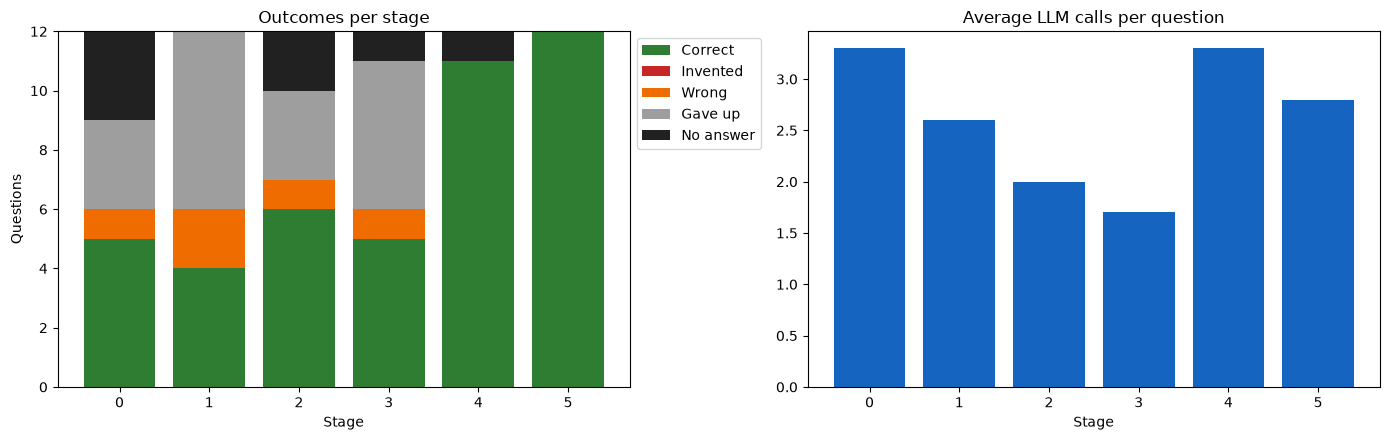

In [38]:
COLORS = {"✅ Correct": "#2e7d32", "🎭 Invented": "#c62828", "🔀 Wrong": "#ef6c00",
          "🙅 Gave up": "#9e9e9e", "💥 No answer": "#212121"}

board = show_scoreboard()
stages = [re.split(r"\s*[:·]\s*", s)[0] for s in board.index]   # "3 : 2 + constrained JSON" -> "3"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

bottom = [0] * len(board)
for outcome, color in COLORS.items():
    values = board[outcome].tolist()
    ax1.bar(stages, values, bottom=bottom, color=color, label=outcome.split(" ", 1)[1])
    bottom = [b + v for b, v in zip(bottom, values)]
ax1.set_title("Outcomes per stage")
ax1.set_xlabel("Stage")
ax1.set_ylabel("Questions")
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1))

ax2.bar(stages, board["Avg LLM calls"], color="#1565c0")
ax2.set_title("Average LLM calls per question")
ax2.set_xlabel("Stage")
plt.tight_layout()
plt.show()

**The story in numbers.** Correct answers went 5 → 4 → 6 → 5 → 11 → 12.
- **Prompt-only changes didn't help.** The finish rule (Stage 1) and the stricter JSON prompt (Stage 3) each fixed something and broke something else. In both cases, the flaky tool (Q6) was a casualty.
- **Mechanisms helped.** Reflection made recovery from tool errors reliable, and after Stage 2 the format errors stayed at zero.
- **A new capability helped most.** The search tool alone added 6 correct answers, more than all the other stages combined. For a small model, giving the agent the right tool mattered far more than telling it how to behave.
- **Parallel calls removed the last failure** and cut the number of LLM calls.
- **No stage ever invented a price** (0 🎭 in 72 answers). Phi-4-mini with tools fails by giving up or by trusting the wrong ticker, not by making up numbers.

**How we got here.** Our first run of this notebook looked very different: Stage 4 scored 4 of 12 and Stage 5 only 7 of 12, and the simplest question (Q1) failed at almost every stage. The traces showed the model adding a `-USD` suffix to ordinary stock tickers (`CRVD-USD`, `OPXG-USD`). The cause was one line in our tool description, *"Cryptocurrencies use the '-USD' suffix"*, which the model applied to every ticker. A second problem was the Stage 3 example, which showed the agent giving up after an error. Rewriting that line ("Only cryptocurrency tickers end in '-USD'") and replacing the example with a recovery took Stage 4 from 4 to 11 correct and Stage 5 from 7 to 12, without changing any code. We would never have found this by looking at demos: the Stage 5 demo on Q12 looked perfect in both runs.

## The next problem: growing prompts

Look at the **Avg prompt tokens** column again. Every fix we added made the system prompt longer: format rules, a finish rule, reflection rules, tool rules, examples. The system prompt grew from 139 tokens at Stage 0 to 1,077 tokens at Stage 5, almost 8× larger (see the table below). And within a run, every step appends reasoning, tool output and notices: the average prompt at the agent's last LLM call grew from 291 to 1,341 tokens.

The chart for Q12 shows the trade-off of our last stage. Stage 5 needs only 3 steps, but its prompt starts at about 1,100 tokens and ends near 1,600. That's more than Stage 4 reached after 6 steps. Parallel calls save LLM calls, but the examples that teach them make every call more expensive.

On 12 short questions, the longer prompts didn't hurt accuracy. But they cost memory and latency on every call, and they will keep growing as the agent gets more tools and longer tasks.

In [39]:
SYSTEM_PROMPTS = {
    "0 : ReAct": SYSTEM_PROMPT_REACT,
    "1 : 0 + finish rule": SYSTEM_PROMPT_FINISH,
    "2 : 1 + reflection": SYSTEM_PROMPT_REFLECTION,
    "3 : 2 + constrained JSON": SYSTEM_PROMPT_JSON_V1,
    "4 : 3 + search tool": SYSTEM_PROMPT_JSON_V2,
    "5 : 4 + parallel calls": SYSTEM_PROMPT_PARALLEL,
}
pd.DataFrame({"System prompt tokens": {s: count_tokens(p) for s, p in SYSTEM_PROMPTS.items()}})

,System prompt tokens
0 : ReAct,139
1 : 0 + finish rule,168
2 : 1 + reflection,224
3 : 2 + constrained JSON,425
4 : 3 + search tool,549
5 : 4 + parallel calls,1077


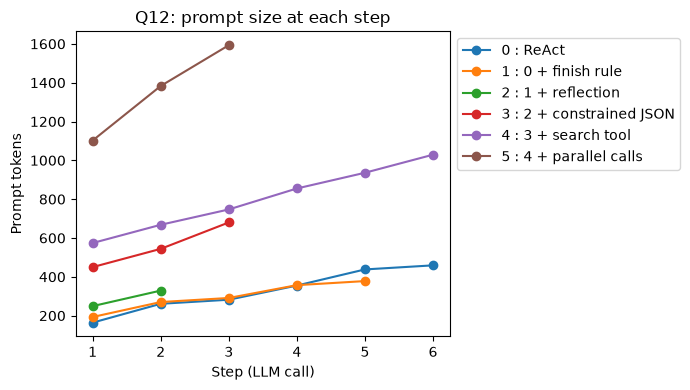

In [40]:
# Prompt size at every LLM call for the three-company question (Q12)
plt.figure(figsize=(7, 4))
for stage, rows in RESULTS.items():
    tokens = next(r for r in rows if r["id"] == "Q12")["prompt_tokens"]
    plt.plot(range(1, len(tokens) + 1), tokens, marker="o", label=stage)
plt.title("Q12: prompt size at each step")
plt.xlabel("Step (LLM call)")
plt.ylabel("Prompt tokens")
plt.gca().xaxis.get_major_locator().set_params(integer=True)   # whole steps only
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Why do growing prompts hurt small LLMs?**

All LLMs degrade as prompts get longer and more cluttered, but smaller models tend to degrade sooner and more steeply. The same failure modes appear in large models; they are simply more pronounced in small ones.

- [Instruction overload:](https://arxiv.org/abs/2507.11538) compliance drops as the number of instructions grows. The IFScale benchmark, an extreme stress test with up to 500 simultaneous keyword instructions, found that even the best frontier models reached only 68% accuracy at the highest density. Reasoning models held up the longest, while models such as GPT-4o and Llama-4-Scout degraded exponentially. Models also tended to favour instructions that appear earlier in the prompt.
- [Lost in the middle:](https://arxiv.org/abs/2307.03172) models use information at the beginning and end of a long prompt more reliably than information in the middle. Content in the middle isn't ignored, but it's more likely to be missed. The effect was shown on the large models of the time, including GPT-3.5-Turbo and Claude 1.3.
- [Distraction by irrelevant context:](https://arxiv.org/abs/2302.00093) extra background, edge cases, or filler text lowers accuracy even when the relevant information is still present. [Related work](https://arxiv.org/abs/2402.14848) shows that reasoning performance also drops as input length grows, well before the context window limit.
- [Effective context is shorter than advertised:](https://arxiv.org/abs/2404.06654) many models that claim 32k+ windows perform well on only a fraction of that length on tasks harder than simple retrieval. In long multi-turn dialogs, adherence to the system prompt also [decays over time](https://arxiv.org/abs/2402.10962) as more text accumulates after it.

As the prompt grows, the system prompt drifts further back. To counter this, keep observations short, compress or drop old steps, and restate critical rules near the end of the prompt. More on how to handle this in upcoming posts, and the scoreboard will tell us whether it works.

## Bonus: the same agent with LangGraph

Everything so far was written by hand: the loop, the state (one growing prompt string), tool dispatch, parallel execution, the step limit and the error routing. Agent frameworks provide exactly these pieces. Let's rebuild our Stage 5 agent with [**LangGraph**](https://langchain-ai.github.io/langgraph/) and run it through the same evaluation.

LangGraph models an agent as a **graph**:
- The **state** is shared data that every step reads and updates. For agents, it's usually a list of chat messages (`MessagesState`).
- **Nodes** are plain Python functions that take the state and return an update.
- **Edges** decide which node runs next. *Conditional* edges are functions that look at the state and pick the next node.

Out of the box, LangGraph gives us a `ToolNode` that executes all tool calls from the last message (in parallel) and appends the results, a `tools_condition` edge that ends the run when the model stops calling tools, and a `recursion_limit` that caps the number of steps. It also offers features we don't need here: streaming, checkpointing (pause and resume a run), human-in-the-loop approval and tracing.

What LangGraph does **not** give us is a reliable model. Its prebuilt agents expect a chat model that returns native tool calls, like the OpenAI or Anthropic APIs, or a local model served through Ollama or vLLM with tool-calling support. Our model runs directly through `transformers` and produces tool calls through constrained JSON. So we write **one node ourselves**, the agent node, and reuse our Stage 5 prompt, schema and Outlines model inside it. The node converts each structured step into a standard LangChain `AIMessage` with `tool_calls`, and from there everything is standard LangGraph.

Here is how our hand-written code maps onto the graph:

| Hand-written (Stage 5) | LangGraph |
|---|---|
| One growing prompt string | `MessagesState`, a list of messages (we render it into our prompt format) |
| `for step in range(max_steps)` | Graph edges + `recursion_limit` |
| `execute_parallel()` | `ToolNode` |
| `if action.step_type == "final_answer": return` | `tools_condition` |
| Abort after 3 failed batches in a row | A custom conditional edge + a `give_up` node |
| Duplicate-call guard | Not included (it could be added as another edge) |

The code was tested with `langgraph` 1.2 and `langchain-core` 1.6.

In [ ]:
%pip install -q langgraph langchain-core

In [41]:
import uuid
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.errors import GraphRecursionError
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

### Tools

LangChain's `@tool` turns a Python function into a tool, using its name, type hints and docstring. We can wrap our existing functions without changing them.

In [42]:
LG_TOOLS = [tool(get_stock_price), tool(search_company)]

# Each of our tools takes a single argument; remember its name ("ticker" or "query")
LG_TOOL_ARGS = {t.name: next(iter(t.args)) for t in LG_TOOLS}

# The same parallel schemas as in Stage 5
LG_STEP, LG_REFLECTION_STEP = make_parallel_schemas(list(LG_TOOL_ARGS))
LG_TOOL_ARGS

{'get_stock_price': 'ticker', 'search_company': 'query'}

### The agent node

The agent node is the only part that knows about our model. It turns the message list back into the exact text prompt that our Stage 5 agent builds (including the reflection notice after a failed batch), generates one constrained step, and returns it as an `AIMessage`:
- a **final answer** becomes a message with plain text content;
- a **tool step** becomes a message with `tool_calls`, the standard format that `ToolNode` understands.

We keep the raw JSON step and the prompt size in the message metadata, so that the next prompt looks exactly like before and the scoreboard can report prompt sizes.

In [43]:
def render_prompt(messages: list) -> tuple:
    """Turn LangGraph's message list into the same text prompt our Stage 5 agent builds.
    Returns the prompt and whether the last tool batch had a failure."""
    prompt = start_prompt(SYSTEM_PROMPT_PARALLEL, messages[0].content)
    calls, failed, total = {}, 0, 0

    def notice():
        return (f"SYSTEM NOTICE: {failed} of {total} call(s) failed. Start your next step "
                "with a critique and a new strategy, and keep the results you already have.\n")

    for m in messages[1:]:
        if isinstance(m, AIMessage):
            if failed:                       # the previous batch had a failure
                prompt += notice()
            failed, total = 0, 0
            prompt += "Assistant: " + m.additional_kwargs.get("step_json", "") + "\n"
            calls.update({tc["id"]: tc for tc in m.tool_calls})
        elif isinstance(m, ToolMessage):
            tc = calls[m.tool_call_id]
            arg = next(iter(tc["args"].values()))
            prompt += f"Observation [{tc['name']}({arg})]: {m.content}\n"
            total += 1
            failed += m.content.startswith("ERROR")
    if failed:
        prompt += notice()
    return prompt, failed > 0

def agent_node(state: MessagesState) -> dict:
    prompt, reflect = render_prompt(state["messages"])
    schema = LG_REFLECTION_STEP if reflect else LG_STEP    # enforce reflection after a failure
    meta = {"prompt_tokens": count_tokens(prompt)}
    raw = outlines_model(prompt + "Assistant: ", schema, max_new_tokens=500, do_sample=False)

    try:
        step = schema.model_validate_json(raw)
    except ValidationError:                                # JSON cut off by max_new_tokens
        return {"messages": [AIMessage(
            content="Agent aborted: the structured step was cut off (max_new_tokens).",
            response_metadata={**meta, "status": "aborted", "format_error": True})]}

    extra = {"step_json": json.dumps(step.model_dump())}
    if step.action.step_type == "final_answer":
        return {"messages": [AIMessage(content=step.action.final_answer,
                                       additional_kwargs=extra, response_metadata=meta)]}

    tool_calls = [{"name": c.tool_name,
                   "args": {LG_TOOL_ARGS[c.tool_name]: c.tool_argument},
                   "id": f"call_{uuid.uuid4().hex[:8]}"}
                  for c in step.action.tool_calls]
    return {"messages": [AIMessage(content=step.thought, tool_calls=tool_calls,
                                   additional_kwargs=extra, response_metadata=meta)]}

### Error routing as an edge

In the hand-written loop, the "abort after 3 failed batches in a row" guard was an `if` statement inside the loop. In LangGraph, it becomes a **conditional edge** after the tools node: it counts how many of the most recent tool batches failed completely and either goes back to the agent or to a small `give_up` node. As before, a partially successful batch counts as progress.

In [44]:
MAX_ERROR_RETRY = 3

def failed_batches_in_a_row(messages: list) -> int:
    """How many of the most recent tool batches failed completely."""
    count, batch = 0, []
    for m in reversed(messages):
        if isinstance(m, ToolMessage):
            batch.append(m)
        elif isinstance(m, AIMessage) and m.tool_calls and batch:
            if not all(t.content.startswith("ERROR") for t in batch):
                break
            count, batch = count + 1, []
        else:
            break
    return count

def after_tools(state: MessagesState) -> Literal["agent", "give_up"]:
    return "give_up" if failed_batches_in_a_row(state["messages"]) >= MAX_ERROR_RETRY else "agent"

def give_up(state: MessagesState) -> dict:
    return {"messages": [AIMessage(content="Agent aborted due to repeated tool errors.",
                                   response_metadata={"status": "aborted"})]}

### Building the graph

This is where the framework pays off: the whole control flow of our agent fits in a few lines.

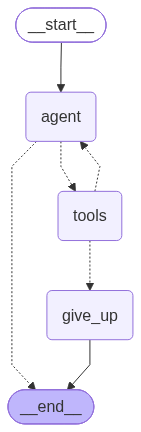

In [45]:
builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(LG_TOOLS))       # runs all tool calls of a step in parallel
builder.add_node("give_up", give_up)

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)   # tool calls -> "tools", otherwise -> END
builder.add_conditional_edges("tools", after_tools)       # -> "agent" or "give_up"
builder.add_edge("give_up", END)

lg_agent = builder.compile()

# Draw the graph (the PNG is rendered by the mermaid.ink web service; fall back to Mermaid text offline)
try:
    from IPython.display import Image, display
    display(Image(lg_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(lg_agent.get_graph().draw_mermaid())

### Running the graph and plugging it into our evaluation

To compare fairly, the graph gets the same step budget. Each agent step and each tool step is one graph step ("superstep"), so `recursion_limit = 2 * MAX_STEPS` allows at most 6 LLM calls, just like our loops. When the limit is hit, LangGraph raises `GraphRecursionError`, which we treat as "no answer".

A small adapter converts the final message list into our `AgentResult`, so the same `evaluate()` function and scoreboard work unchanged.

In [46]:
def to_agent_result(messages: list) -> AgentResult:
    """Convert LangGraph's message list into our AgentResult for scoring."""
    res = AgentResult()
    calls = {}
    for m in messages:
        if isinstance(m, AIMessage):
            if "prompt_tokens" in m.response_metadata:        # this message came from an LLM call
                res.llm_calls += 1
                res.prompt_tokens.append(m.response_metadata["prompt_tokens"])
                res.format_errors += int(m.response_metadata.get("format_error", False))
            calls.update({tc["id"]: tc for tc in m.tool_calls})
        elif isinstance(m, ToolMessage):
            tc = calls[m.tool_call_id]
            res.record(tc["name"], next(iter(tc["args"].values())), m.content)

    last = messages[-1]
    if isinstance(last, AIMessage) and not last.tool_calls:
        if last.response_metadata.get("status") == "aborted":
            return res.abort(last.content)
        return res.finish(last.content)
    return res          # the graph was stopped by the step limit: status stays "max_steps"

def run_langgraph_agent(question: str, max_steps: int = MAX_STEPS, verbose: bool = True) -> AgentResult:
    state, printed = None, 0
    try:
        for state in lg_agent.stream({"messages": [HumanMessage(content=question)]},
                                     {"recursion_limit": 2 * max_steps}, stream_mode="values"):
            if verbose:                                        # print only the new messages
                for m in state["messages"][printed:]:
                    m.pretty_print()
                printed = len(state["messages"])
    except GraphRecursionError:
        if verbose:
            print("⏱️ Step limit reached.")
    return to_agent_result(state["messages"])

Let's run the three-company question. LangGraph's `pretty_print()` shows every message in the state: the user's question, the agent's tool calls, the tool results and the final answer.

In [47]:
demo(run_langgraph_agent, "Q12")

================================ Human Message =================================

Give me the current stock prices of Pinecrest Pharma, Tessera Materials and Lumen Harbor Bank.
================================== Ai Message ==================================

I need to search for the tickers of Pinecrest Pharma, Tessera Materials, and Lumen Harbor Bank before I can get their stock prices.
Tool Calls:
  search_company (call_437c2820)
 Call ID: call_437c2820
  Args:
    query: Pinecrest Pharma
  search_company (call_cde4c4c1)
 Call ID: call_cde4c4c1
  Args:
    query: Tessera Materials
  search_company (call_8dfbe2df)
 Call ID: call_8dfbe2df
  Args:
    query: Lumen Harbor Bank
================================= Tool Message =================================
Name: search_company

Found matches:
- PNCP | Pinecrest Pharma Inc. | Type: EQUITY
Check that a match is the company itself, not a fund that only mentions its name.
================================= Tool Message =======================

### Evaluation: hand-written vs. LangGraph

Now the same 12 questions. Run this cell in the same session as the earlier stages, so the scoreboard can show them side by side.

In [48]:
evaluate("LG : 5 in LangGraph", run_langgraph_agent)

Evaluating: LG : 5 in LangGraph
    Q1 ✅ Correct     (2 LLM calls)
    Q2 ✅ Correct     (3 LLM calls)
    Q3 ✅ Correct     (3 LLM calls)
    Q4 ✅ Correct     (3 LLM calls)
    Q5 ✅ Correct     (3 LLM calls)
    Q6 ✅ Correct     (3 LLM calls)
    Q7 ✅ Correct     (3 LLM calls)
    Q8 ✅ Correct     (2 LLM calls)
    Q9 ✅ Correct     (2 LLM calls)
   Q10 ✅ Correct     (3 LLM calls)
   Q11 ✅ Correct     (3 LLM calls)
   Q12 ✅ Correct     (3 LLM calls)


,✅ Correct,🎭 Invented,🔀 Wrong,🙅 Gave up,💥 No answer,Format errors,Avg LLM calls,Avg prompt tokens
Stage,,,,,,,,
0 : ReAct,5,0,1,3,3,3,3.3,291
1 : 0 + finish rule,4,0,2,6,0,3,2.6,272
2 : 1 + reflection,6,0,1,3,2,0,2.0,315
3 : 2 + constrained JSON,5,0,1,5,1,0,1.7,509
4 : 3 + search tool,11,0,0,0,1,0,3.3,785
5 : 4 + parallel calls,12,0,0,0,0,0,2.8,1341
LG : 5 in LangGraph,12,0,0,0,0,0,2.8,1341


In [49]:
# Stage 5 (hand-written) vs. LangGraph, question by question
show_matrix().iloc[:, -2:]

,5 : 4 + parallel calls,LG : 5 in LangGraph
Q1 Direct ticker,✅,✅
Q2 Company name,✅,✅
Q3 Similar names,✅,✅
Q4 Misspelled name,✅,✅
Q5 Cryptocurrency,✅,✅
Q6 Flaky tool,✅,✅
Q7 Renamed ticker,✅,✅
Q8 Private company,✅,✅
Q9 Subsidiary,✅,✅
Q10 No suitable tool,✅,✅


### The result: identical, step for step

The LangGraph agent scores **12 of 12**, just like Stage 5. The two rows match not just in outcomes, but also in the average number of LLM calls (2.8) and the average prompt size (1,341 tokens). With greedy decoding and the same rendered prompt, the graph reproduces the hand-written agent step for step. The demo on Q12 shows the same three steps: three searches, three price lookups, and the answer.

That's expected, because the LangGraph agent uses the same model, prompt, schema and constrained decoding as Stage 5. The only differences are in orchestration:
- **No duplicate-call guard.** When the model repeats a call that has already succeeded, the hand-written loop skips it and nudges the model, while LangGraph simply runs it again. On this test set, that difference never showed up.
- **The same error guard, in a different place.** "Three failed batches in a row" is now an edge instead of an `if` statement, with the same behaviour.
- **The same step budget.** `recursion_limit` counts graph steps, which we mapped to the same 6 LLM calls.

So the framework replaced our loop, state handling and parallel tool execution with standard, well-tested building blocks, and it didn't change what the agent can do. Our scoreboard was decided by the model-facing parts (the prompt, the tools, the schema and constrained decoding), and those stayed our job.

That's also the honest trade-off for small local models. With an API model that supports native tool calling, LangGraph's prebuilt agents need almost no code. With a small local model, the hard part, getting reliable steps out of the model, is exactly the part a framework can't do for us. What we get in return are the extras: streaming, checkpoints, human approval, tracing, and a graph that stays readable as the agent grows.

## Wrapping up

We started with a plain ReAct loop and changed it in five steps, measuring every step on the same test set:

1. **A finish rule** made the agent give up sooner, not smarter (5 → 4 correct).
2. **Reflection** made recovery from tool errors reliable and brought format errors to zero (6 correct).
3. **Constrained decoding** guaranteed valid output and let us *enforce* reflection, but on its own it didn't make the agent more accurate (5 correct).
4. **A search tool** was the biggest single win: it solved entity resolution and took us to 11 of 12.
5. **Parallel tool calls** solved the last question and reduced the number of LLM calls: 12 of 12.

Rebuilding Stage 5 with **LangGraph** gave exactly the same results, step for step. The framework made the loop, state, tool execution and routing a few lines of standard building blocks, but the prompt, the tools, the schema and constrained decoding stayed our job.

The most important tool in this post isn't any of these upgrades: it's the **scoreboard**. It showed that prompt tweaks trade one failure for another, that a new tool beats a new rule, and it caught a one-line mistake in our tool description that had cost us several points. Next, we'll make the test set harder and tackle the growing prompts.

## Appendix: going live with Yahoo Finance (optional)

Our agent doesn't depend on the fictional market: it only sees two tools with a name and a text interface. To connect it to real data, we swap in two tools with the same interface, built on the open-source `yfinance` library.

Keep in mind that `yfinance` is an unofficial library that isn't affiliated with Yahoo. It can be rate-limited, quotes may be delayed, and Yahoo's data is intended for personal use. It's great for a demo, but not something to build a product on. Live results also can't be scored with our answer key, because prices change all the time.

Set `RUN_LIVE = True` to try it (install `yfinance` first, see the Setup section).

In [ ]:
RUN_LIVE = False

def live_get_stock_price(ticker: str) -> str:
    """Latest price from Yahoo Finance via yfinance."""
    import yfinance as yf
    t = ticker.strip().strip("'\"").upper()
    history = yf.Ticker(t).history(period="5d")
    if history.empty:
        return f"ERROR: Ticker '{ticker}' not found."
    info = yf.Ticker(t).fast_info
    # Note: FastInfo.get() only accepts camelCase keys ("lastPrice"), not "last_price"
    price = info.get("lastPrice")
    if price is None or price != price:          # missing or NaN: fall back to the last close
        price = history["Close"].iloc[-1]
    currency = info.get("currency") or "USD"
    return f"The latest price of {t} is {price:.2f} {currency}."

def live_search_company(query: str) -> str:
    """Ticker search on Yahoo Finance, in the same format as our fictional search tool."""
    import yfinance as yf
    quotes = yf.Search(query.strip(), max_results=3).quotes
    if not quotes:
        return f"ERROR: No companies found for '{query}'."
    lines = [f"- {q.get('symbol')} | {q.get('longname') or q.get('shortname', 'Unknown')} | "
             f"Type: {q.get('quoteType', 'UNKNOWN')}" for q in quotes[:3]]
    return ("Found matches:\n" + "\n".join(lines) +
            "\nCheck that a match is the company itself, not a fund that only mentions its name.")

TOOLS_LIVE = {"get_stock_price": live_get_stock_price, "search_company": live_search_company}

if RUN_LIVE:
    res = run_parallel_agent("Give me the current prices of Meta, Apple and Bitcoin.", tools=TOOLS_LIVE)
    print(f"\n💬 Final answer: {res.answer}")